Inizializzazione

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import h5py
from torch.utils.data import Dataset, DataLoader
import os # Importato per gestire il salvataggio dei file

#stato = voxel: 1000, velocità lineare: 3, velocità angolare: 3, orientamento: 4 utilizzo dei quaternioni per efficienza
input_dim = 2024 #(1010 stato attuale + 4 motori + 1010 stato successivo)

# 1. DEEN
class DEEN_Network(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.LayerNorm(1024),           # Ottimizzazione 1: Stabilizza i gradienti
            nn.SiLU(),                   # Ottimizzazione 2: Attivazione fluida (Swish)
            nn.Dropout(dropout_rate),    # Ottimizzazione 3: Previene l'overfitting sui voxel

            nn.Linear(1024, 1024),
            nn.LayerNorm(1024),
            nn.SiLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.SiLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 128),
            nn.LayerNorm(128),
            nn.SiLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 1)            # Output: Singolo scalare (Energia)
        )

    def forward(self, x):
        return self.net(x)

# 2. LOSS FUNCTION
def deen_loss_function(ebm_model, x_clean, sigma=0.1):
    # Aggiungo rumore
    noise = torch.randn_like(x_clean) * sigma

    y_corrupted = (x_clean + noise).detach().requires_grad_(True)

    # Calcolo Energia
    energy = ebm_model(y_corrupted)

    # Calcolo Gradienti (Score Function)
    score_function = torch.autograd.grad(
        outputs=energy.sum(),
        inputs=y_corrupted,
        create_graph=True, # FONDAMENTALE per la backpropagation successiva
        retain_graph=True
    )[0]

    # E. Loss Function del paper (Denoising Score Matching)
    error = x_clean - y_corrupted + (sigma**2) * score_function
    loss = torch.mean(error**2)

    return loss

# 3. SETUP DI ADDESTRAMENTO
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DEEN_Network(input_dim, dropout_rate=0.2).to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

Caricamento Dataset

In [4]:
import numpy as np

class DroneVoxelDataset(Dataset):
    def __init__(self, h5_filepath, city_list=None):
        print(f"Caricamento dataset da {h5_filepath}...")
        with h5py.File(h5_filepath, 'r') as f:
            dati_numpy = f['transitions'][:]

            # Il famoso fix MATLAB
            if dati_numpy.shape[0] == 2024:
                dati_numpy = dati_numpy.T

            # Estraiamo gli ID delle città
            if 'city_ids' in f:
                ids_numpy = f['city_ids'][:]
            else:
                print("⚠️ Attenzione: Nessun city_id trovato, carico tutto.")
                ids_numpy = np.ones((dati_numpy.shape[0], 1))

        # --- FILTRAGGIO PER CITTÀ ---
        if city_list is not None:
            # Crea una maschera True/False per tenere solo le righe delle città richieste
            mask = np.isin(ids_numpy, city_list).flatten()
            dati_numpy = dati_numpy[mask]
            print(f" 🎯 Filtrate città: {city_list}")

        self.data = torch.tensor(dati_numpy, dtype=torch.float32)
        print(f" ✔️ Dataset pronto! Totale campioni: {len(self.data)}\n")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# =========================================================================
# ESECUZIONE: SUDDIVISIONE 8 - 1 - 1
# =========================================================================
file_dataset = '/content/drive/MyDrive/Colab Notebooks/dataset_deen_completo.h5'

print("--- PREPARAZIONE TRAIN SET ---")
train_dataset = DroneVoxelDataset(file_dataset, city_list=[1, 2, 3, 4, 5, 6, 7, 8])
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

print("--- PREPARAZIONE VALIDATION SET ---")
val_dataset = DroneVoxelDataset(file_dataset, city_list=[9])
# Shuffle=False perché in validazione non serve mischiare i dati
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

print("--- PREPARAZIONE TEST SET ---")
test_dataset = DroneVoxelDataset(file_dataset, city_list=[10])
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

--- PREPARAZIONE TRAIN SET ---
Caricamento dataset da /content/drive/MyDrive/Colab Notebooks/dataset_deen_completo.h5...
 🎯 Filtrate città: [1, 2, 3, 4, 5, 6, 7, 8]
 ✔️ Dataset pronto! Totale campioni: 35844

--- PREPARAZIONE VALIDATION SET ---
Caricamento dataset da /content/drive/MyDrive/Colab Notebooks/dataset_deen_completo.h5...
 🎯 Filtrate città: [9]
 ✔️ Dataset pronto! Totale campioni: 3999

--- PREPARAZIONE TEST SET ---
Caricamento dataset da /content/drive/MyDrive/Colab Notebooks/dataset_deen_completo.h5...
 🎯 Filtrate città: [10]
 ✔️ Dataset pronto! Totale campioni: 4269



Addestramento

In [6]:
def train_deen(model, train_loader, val_loader, num_epochs=100, sigma=0.1, save_path="best_deen_model.pth"):
    # Inizializzo la miglior validation loss a infinito
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        # -----------------------------------------------------
        # FASE 1: TRAINING
        # -----------------------------------------------------
        model.train()
        train_loss = 0.0

        for batch_x_clean in train_loader:
            batch_x_clean = batch_x_clean.to(device)
            optimizer.zero_grad()

            loss = deen_loss_function(model, batch_x_clean, sigma)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # -----------------------------------------------------
        # FASE 2: VALIDATION (Su dati mai visti!)
        # -----------------------------------------------------
        model.eval() # Disabilita il dropout per il test
        val_loss = 0.0

        # RIMOSSO: with torch.no_grad():  <-- Il motore delle derivate ora resta acceso per calcolare lo Score!
        for batch_val_clean in val_loader:
            batch_val_clean = batch_val_clean.to(device)

            # Calcoliamo la loss usando la stessa funzione Denoising
            v_loss = deen_loss_function(model, batch_val_clean, sigma)
            val_loss += v_loss.item()

        avg_val_loss = val_loss / len(val_loader)

        # -----------------------------------------------------
        # FASE 3: SALVATAGGIO E LOGGING
        # -----------------------------------------------------
        # Ora salviamo il modello SOLO se migliora sulla città di Validation!
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            salvato_msg = f" 💾 (Miglioramento Val! Modello salvato)"
        else:
            salvato_msg = ""

        print(f"Epoca {epoch+1:03d}/{num_epochs} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}{salvato_msg}")

        # Lo scheduler ora fa scendere il Learning Rate in base alla Validation
        scheduler.step(avg_val_loss)

    print(f"\n✅ Addestramento completato. Miglior Val Loss: {best_val_loss:.6f}")
    model.load_state_dict(torch.load(save_path))
    print("Modello migliore ricaricato e pronto per l'esportazione!")
    return model

# --- Avvio dell'addestramento con il nuovo setup ---
model = train_deen(model, train_loader, val_loader, num_epochs=100, sigma=0.1, save_path="best_deen_weights.pth")

Epoca 001/100 | Train Loss: 0.00898 | Val Loss: 0.00810 💾 (Miglioramento Val! Modello salvato)
Epoca 002/100 | Train Loss: 0.00831 | Val Loss: 0.00774 💾 (Miglioramento Val! Modello salvato)
Epoca 003/100 | Train Loss: 0.00806 | Val Loss: 0.00709 💾 (Miglioramento Val! Modello salvato)
Epoca 004/100 | Train Loss: 0.00740 | Val Loss: 0.00659 💾 (Miglioramento Val! Modello salvato)
Epoca 005/100 | Train Loss: 0.00669 | Val Loss: 0.00625 💾 (Miglioramento Val! Modello salvato)
Epoca 006/100 | Train Loss: 0.00616 | Val Loss: 0.00605 💾 (Miglioramento Val! Modello salvato)
Epoca 007/100 | Train Loss: 0.00599 | Val Loss: 0.00691
Epoca 008/100 | Train Loss: 0.00640 | Val Loss: 0.00595 💾 (Miglioramento Val! Modello salvato)
Epoca 009/100 | Train Loss: 0.00593 | Val Loss: 0.00584 💾 (Miglioramento Val! Modello salvato)
Epoca 010/100 | Train Loss: 0.00585 | Val Loss: 0.00581 💾 (Miglioramento Val! Modello salvato)
Epoca 011/100 | Train Loss: 0.00583 | Val Loss: 0.00581
Epoca 012/100 | Train Loss: 0.005

Testing

🔍 Inizio test di generalizzazione (Zero-Shot) sulla Città 10...

✅ Test Completato!
🔋 Energia Media Sicura (Reale): -272.0004
⚠️ Energia Media Pericolosa (Rumore): -97.9129
📈 Distanza (Separazione): 174.0875

🎉 SUCCESSO! Il modello ha creato un 'pozzo di energia' attorno alle traiettorie sicure.


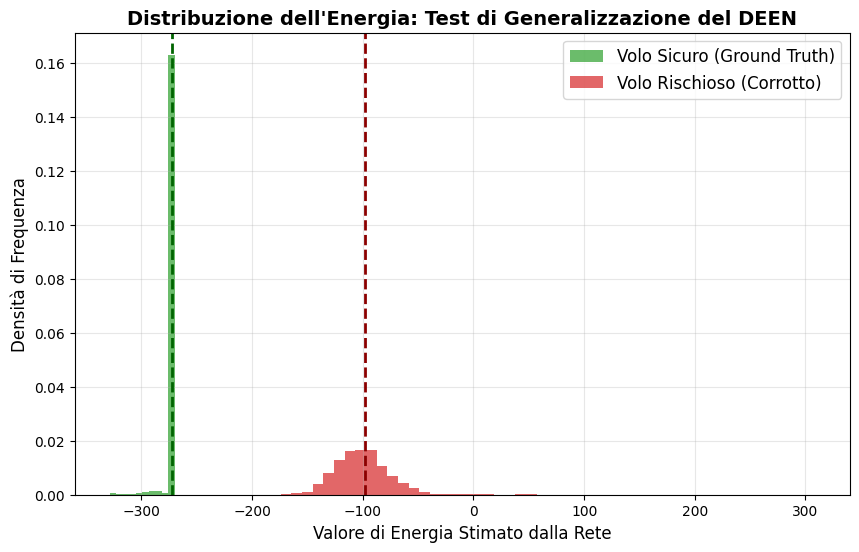

📸 Grafico salvato come 'deen_energy_distribution.png' (Pronto per la tesi!)


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# =========================================================================
# FUNZIONE DI TESTING DELL'ENERGIA E PLOTTING
# =========================================================================
def test_deen_energy(model, test_dataloader, sigma=0.1):
    model.eval() # FONDAMENTALE: spegne il Dropout per il test

    energie_pulite = []
    energie_corrotte = []

    print("🔍 Inizio test di generalizzazione (Zero-Shot) sulla Città 10...")

    with torch.no_grad(): # Niente gradienti: velocissimo e non consuma RAM
        for batch_x_clean in test_dataloader:
            batch_x_clean = batch_x_clean.to(device)

            # 1. Energia Traiettorie Sicure (Il volo calcolato da MATLAB)
            energy_clean = model(batch_x_clean)
            energie_pulite.extend(energy_clean.cpu().numpy().flatten())

            # 2. Energia Traiettorie Pericolose (Aggiungiamo rumore critico)
            noise = torch.randn_like(batch_x_clean) * sigma
            batch_x_corrupted = batch_x_clean + noise

            energy_corrupted = model(batch_x_corrupted)
            energie_corrotte.extend(energy_corrupted.cpu().numpy().flatten())

    # --- Calcolo Statistiche ---
    media_pulita = np.mean(energie_pulite)
    media_corrotta = np.mean(energie_corrotte)
    delta = media_corrotta - media_pulita

    print(f"\n✅ Test Completato!")
    print(f"🔋 Energia Media Sicura (Reale): {media_pulita:.4f}")
    print(f"⚠️ Energia Media Pericolosa (Rumore): {media_corrotta:.4f}")
    print(f"📈 Distanza (Separazione): {delta:.4f}")

    if delta > 0:
        print("\n🎉 SUCCESSO! Il modello ha creato un 'pozzo di energia' attorno alle traiettorie sicure.")
    else:
        print("\n❌ ATTENZIONE! Il modello fa fatica a distinguere il pericolo.")

    # --- GENERAZIONE GRAFICO PER LA TESI ---
    plt.figure(figsize=(10, 6))

    # Istogramma Verde (Sicuro)
    plt.hist(energie_pulite, bins=50, alpha=0.7, color='#2ca02c', label='Volo Sicuro (Ground Truth)', density=True)
    # Istogramma Rosso (Pericolo)
    plt.hist(energie_corrotte, bins=50, alpha=0.7, color='#d62728', label='Volo Rischioso (Corrotto)', density=True)

    # Linee delle medie
    plt.axvline(media_pulita, color='darkgreen', linestyle='dashed', linewidth=2)
    plt.axvline(media_corrotta, color='darkred', linestyle='dashed', linewidth=2)

    plt.title('Distribuzione dell\'Energia: Test di Generalizzazione del DEEN', fontsize=14, fontweight='bold')
    plt.xlabel('Valore di Energia Stimato dalla Rete', fontsize=12)
    plt.ylabel('Densità di Frequenza', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)

    # Salva l'immagine ad alta risoluzione
    plt.savefig('deen_energy_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("📸 Grafico salvato come 'deen_energy_distribution.png' (Pronto per la tesi!)")

    return energie_pulite, energie_corrotte

# =========================================================================
# ESECUZIONE DEL TEST
# =========================================================================
# Passiamo il test_loader generato in precedenza
clean_e, corrupted_e = test_deen_energy(model, test_loader, sigma=0.1)

Esportazione

In [9]:
!pip install onnx onnxscript

def esporta_in_onnx(model, nome_file="deen_addestrato.onnx"):
    model.eval()

    dummy_input = torch.randn(1, input_dim, requires_grad=True).to(device)

    print(f"Esportazione del modello in {nome_file}...")

    torch.onnx.export(
        model,
        dummy_input,
        nome_file,
        export_params=True,
        opset_version=11,
        do_constant_folding=True,
        input_names=['input_transition'],
        output_names=['energy_score']
    )
    print("Esportazione completata con successo! Ora puoi importarlo in MATLAB.")

esporta_in_onnx(model, "deen_addestrato.onnx")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 19.1 MB/s eta 0:00:00
Esportazione del modello in deen_addestrato.onnx...


W0408 09:55:30.886000 518 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `DEEN_Network([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DEEN_Network([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Esportazione completata con successo! Ora puoi importarlo in MATLAB.
